# Análisis Cluster - Fórmula 1

En este notebook se realiza el **Análisis Cluster** para segmentar las participaciones de los pilotos en diferentes grupos de rendimiento.

Se evaluarán y compararán dos enfoques:
1. **Clustering sin PCA:** Trabajando directamente con las variables numéricas seleccionadas escaladas (Min-Max).
2. **Clustering con PCA:** Trabajando con la matriz de componentes principales (scores) obtenida en la fase anterior.

El análisis incluye diagnósticos para la elección del K óptimo, un análisis jerárquico sobre una muestra para evaluar el encadenamiento, y perfiles visuales (boxplots y barras apiladas) para interpretar el significado deportivo de cada cluster.

In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import MinMaxScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.metrics.pairwise import euclidean_distances

from scipy.cluster.hierarchy import linkage, dendrogram, cut_tree, cophenet
from scipy.spatial.distance import squareform

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 120)
sns.set_theme(style="whitegrid")

# Definición de rutas
DATA_PROCESSED = "../data/processed"
FIGURES_DIR = "../reports/figures/clustering"

# Crear carpeta de figuras específica para clustering si no existe
os.makedirs(FIGURES_DIR, exist_ok=True)
RANDOM_STATE = 42

## 1. Funciones Auxiliares de Diagnóstico y Visualización

Se definen las funciones para evaluar la calidad de los clusters, graficar los dendrogramas del enfoque jerárquico (sobre una muestra para evitar saturar la memoria) y generar los perfiles numéricos y categóricos de cada grupo.

In [59]:
def plot_diagnosticos_kmeans(X, k_min=2, k_max=8, titulo="Diagnósticos K-Means", guardar_como=None):
    ks = list(range(k_min, k_max + 1))
    inercias = []
    silhouettes = []
    
    # Usar muestra para Silhouette si hay muchos datos
    muestra_idx = np.random.choice(X.shape[0], size=min(1500, X.shape[0]), replace=False)
    X_muestra = X[muestra_idx] if isinstance(X, np.ndarray) else X.values[muestra_idx]
    
    for k in ks:
        km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
        labels = km.fit_predict(X)
        inercias.append(km.inertia_)
        silhouettes.append(silhouette_score(X_muestra, labels[muestra_idx]))
        
    fig, axs = plt.subplots(1, 2, figsize=(12, 4))
    axs[0].plot(ks, inercias, marker="o", color="steelblue")
    axs[0].set_title("Método del codo (Inercia)")
    axs[0].set_xlabel("Número de clusters (K)")
    
    axs[1].plot(ks, silhouettes, marker="o", color="darkorange")
    axs[1].set_title("Silhouette score")
    axs[1].set_xlabel("Número de clusters (K)")
    
    fig.suptitle(titulo, y=1.05)
    plt.tight_layout()
    if guardar_como:
        plt.savefig(os.path.join(FIGURES_DIR, guardar_como), dpi=150, bbox_inches="tight")
    plt.show()

def analisis_jerarquico_muestra(X, k_final, titulo, sample_size=800, random_state=RANDOM_STATE, guardar_como=None):
    X_arr = np.asarray(X)
    n = X_arr.shape[0]
    idx = np.random.choice(n, size=min(sample_size, n), replace=False)
    X_sample = X_arr[idx]

    D = euclidean_distances(X_sample, X_sample)
    condensed_D = squareform(D, checks=False)

    Zs = {
        "simple": linkage(condensed_D, method="single"),
        "completo": linkage(condensed_D, method="complete"),
        "promedio": linkage(condensed_D, method="average"),
        "ward": linkage(condensed_D, method="ward")
    }

    fig, axs = plt.subplots(2, 2, figsize=(14, 10))
    for ax, (nombre, Z) in zip(axs.ravel(), Zs.items()):
        dendrogram(Z, ax=ax, no_labels=True, color_threshold=None)
        ax.set_title(f"Encadenamiento {nombre}")
    fig.suptitle(titulo, y=1.02)
    plt.tight_layout()
    if guardar_como:
        plt.savefig(os.path.join(FIGURES_DIR, guardar_como), dpi=150, bbox_inches="tight")
    plt.show()

    # Coeficiente cofenético
    ccc = []
    for nombre, Z in Zs.items():
        valor, _ = cophenet(Z, condensed_D)
        ccc.append({"encadenamiento": nombre, "coeficiente_cofenetico": valor})
    ccc_df = pd.DataFrame(ccc).sort_values("coeficiente_cofenetico", ascending=False)
    
    # Silhouette por encadenamiento
    sil_rows = []
    for nombre, Z in Zs.items():
        for k in range(2, 8):
            labels = cut_tree(Z, n_clusters=k).reshape(-1)
            sil = silhouette_score(D, labels, metric="precomputed")
            sil_rows.append({"encadenamiento": nombre, "k": k, "silhouette": sil})
            
    return {"cofenetico": ccc_df, "silhouette": pd.DataFrame(sil_rows)}

def plot_boxplots_clusters(df, cluster_col, variables, titulo, guardar_como=None):
    n_cols = 3
    n_rows = int(np.ceil(len(variables) / n_cols))
    fig, axs = plt.subplots(n_rows, n_cols, figsize=(5*n_cols, 4*n_rows))
    axs = np.array(axs).reshape(-1)

    for ax, var in zip(axs, variables):
        sns.boxplot(data=df, x=cluster_col, y=var, hue=cluster_col, legend=False, ax=ax, palette="Set2")
        ax.set_title(var)
    for ax in axs[len(variables):]:
        ax.axis("off")

    fig.suptitle(titulo, y=1.02)
    plt.tight_layout()
    if guardar_como:
        plt.savefig(os.path.join(FIGURES_DIR, guardar_como), dpi=150, bbox_inches="tight")
    plt.show()

# --- NUEVAS FUNCIONES DE PERFILADO CATEGÓRICO ---

def perfil_categorico(df, cluster_col, variable_cat):
    tabla = pd.crosstab(df[cluster_col], df[variable_cat], normalize="index").round(3)
    return tabla

def plot_categorica_fill(df, cluster_col, variable_cat, titulo, guardar_como=None):
    tabla = pd.crosstab(df[cluster_col], df[variable_cat], normalize="index")
    ax = tabla.plot(kind="bar", stacked=True, figsize=(10, 5), colormap="viridis")
    ax.set_title(titulo)
    ax.set_xlabel("Cluster")
    ax.set_ylabel("Proporción")
    ax.legend(title=variable_cat, bbox_to_anchor=(1.05, 1), loc="upper left")
    plt.tight_layout()
    if guardar_como:
        plt.savefig(os.path.join(FIGURES_DIR, guardar_como), dpi=150, bbox_inches="tight")
    plt.show()

## 2. Carga de Datos y Preparación de Matrices

Cargamos la base del EDA (filtrando las observaciones de *pit lane* como se hizo en PCA) y la matriz PCA unificada. Construiremos las dos matrices que competirán en el análisis:
* `X_sin_pca`: Variables originales numéricas, escaladas con Min-Max.
* `X_con_pca`: Variables ortogonales de componentes principales.

In [ ]:
# Carga de la base de trabajo (del EDA)
df_model = pd.read_csv(os.path.join(DATA_PROCESSED, "formula1_base.csv"))
df_model = df_model[df_model["grid"] > 0].copy() # Filtro clave para igualar al PCA

# Carga de la matriz PCA
df_pca_completo = pd.read_csv(os.path.join(DATA_PROCESSED, "formula1_pca_scores.csv"))
cols_cp = [col for col in df_pca_completo.columns if col.startswith("CP")]
X_con_pca = df_pca_completo[cols_cp].values

# Variables activas sin PCA
variables_cluster_base = [
    "grid", "positionOrder", "laps_pct", "driver_age", 
    "driver_championship_position", "driver_championship_wins"
]

# Filtrar base final
df_cluster = df_model.dropna(subset=variables_cluster_base).reset_index(drop=True)
df_cluster["posiciones_ganadas"] = df_cluster["grid"] - df_cluster["positionOrder"]

# Crear Matriz Sin PCA
scaler = MinMaxScaler()
X_sin_pca = scaler.fit_transform(df_cluster[variables_cluster_base])

# Crear década al vuelo si no existe
if "year" in df_cluster.columns:
    df_cluster["decada"] = (df_cluster["year"] // 10 * 10).astype(str) + "s"

print(f"Dimensiones de matriz SIN PCA: {X_sin_pca.shape}")
print(f"Dimensiones de matriz CON PCA: {X_con_pca.shape}")

Dimensiones de matriz SIN PCA: (9760, 6)
Dimensiones de matriz CON PCA: (9760, 3)


## 3. Enfoque 1: Clustering SIN PCA

Evaluamos primero los datos en su espacio original escalado. Exploraremos el diagnóstico por codo y silhouette, y realizaremos un agrupamiento jerárquico de muestra para ver cómo interactúan las distancias puras.

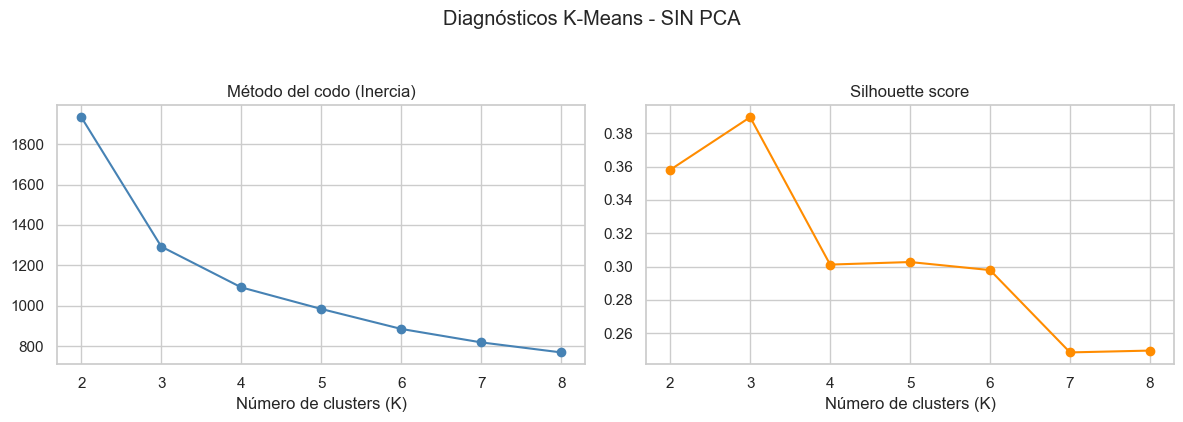

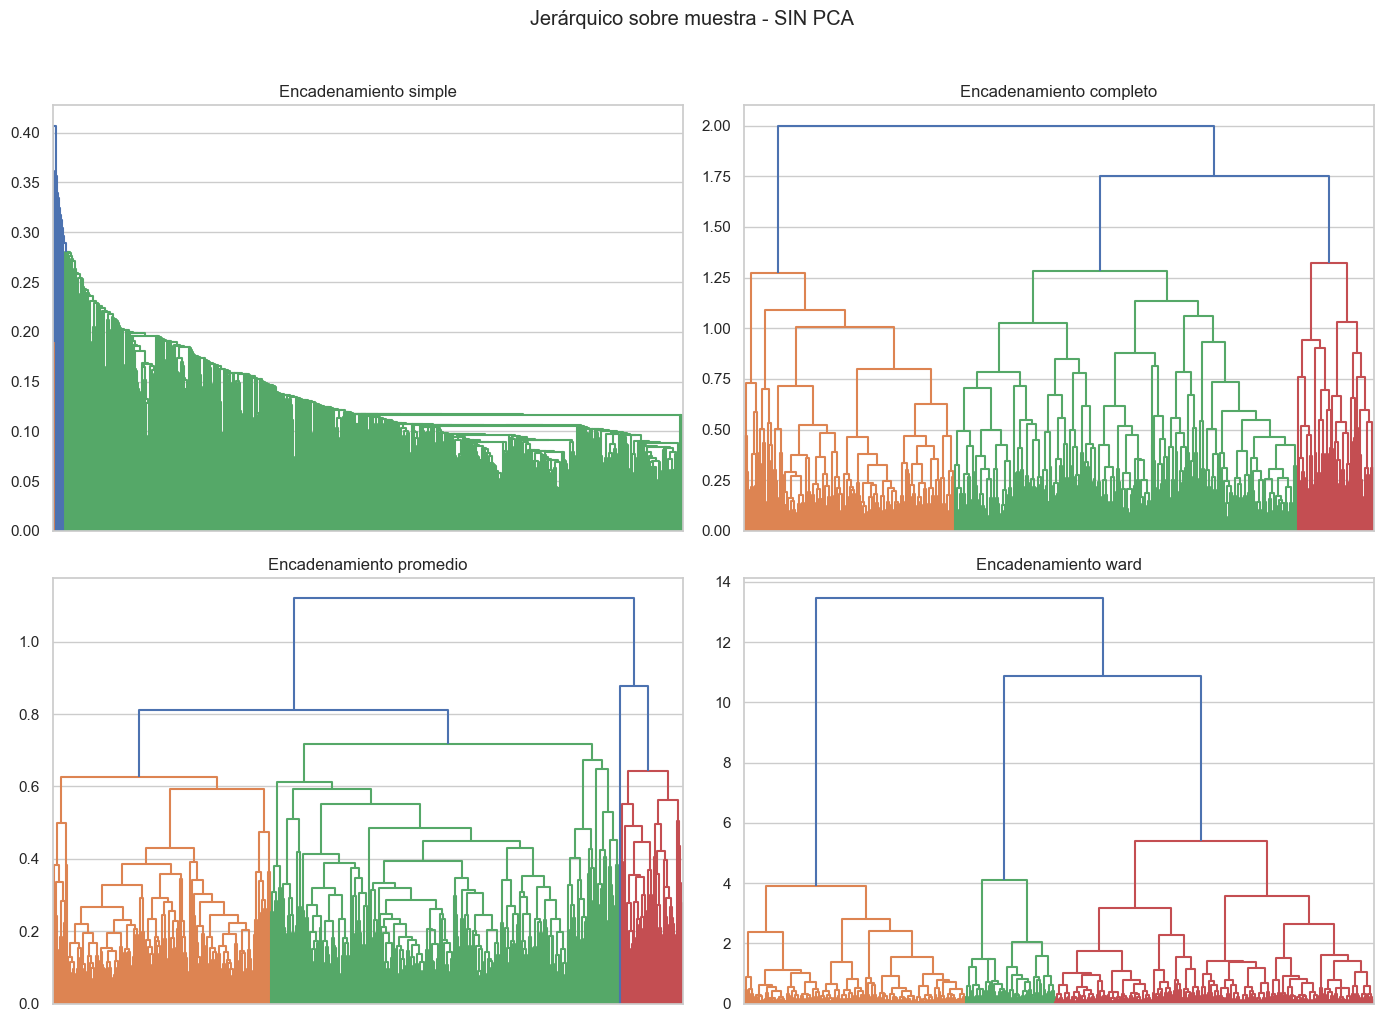

Coeficientes cofenéticos:


,encadenamiento,coeficiente_cofenetico
2,promedio,0.7523
1,completo,0.6320
3,ward,0.6313
0,simple,0.4768



Silhouette por encadenamiento:


encadenamiento,completo,promedio,simple,ward
k,,,,
2,0.3091,0.4131,0.3476,0.3166
3,0.3607,0.3614,0.1710,0.3735
4,0.3339,0.3356,0.0268,0.2651
5,0.2197,0.3004,-0.0029,0.2565
6,0.1939,0.2815,-0.0892,0.2017
7,0.1818,0.2624,-0.0935,0.2033


In [61]:
# Diagnósticos
plot_diagnosticos_kmeans(
    X_sin_pca, 
    titulo="Diagnósticos K-Means - SIN PCA", 
    guardar_como="cluster_sin_pca_diagnosticos.png"
)

# Jerárquico sobre muestra
K_FINAL = 3

jerarquico_sin_pca = analisis_jerarquico_muestra(
    X_sin_pca, k_final=K_FINAL, 
    titulo="Jerárquico sobre muestra - SIN PCA", 
    guardar_como="cluster_sin_pca_dendrograma.png"
)

print("Coeficientes cofenéticos:")
display(jerarquico_sin_pca["cofenetico"].round(4))

print("\nSilhouette por encadenamiento:")
display(jerarquico_sin_pca["silhouette"].pivot(index="k", columns="encadenamiento", values="silhouette").round(4))

### 3.1 Aplicación de K-Means y Perfilado (SIN PCA)

Elegimos `K=3` por su consistencia. Ajustamos el modelo y analizamos la distribución de las variables en los clusters creados mediante boxplots.

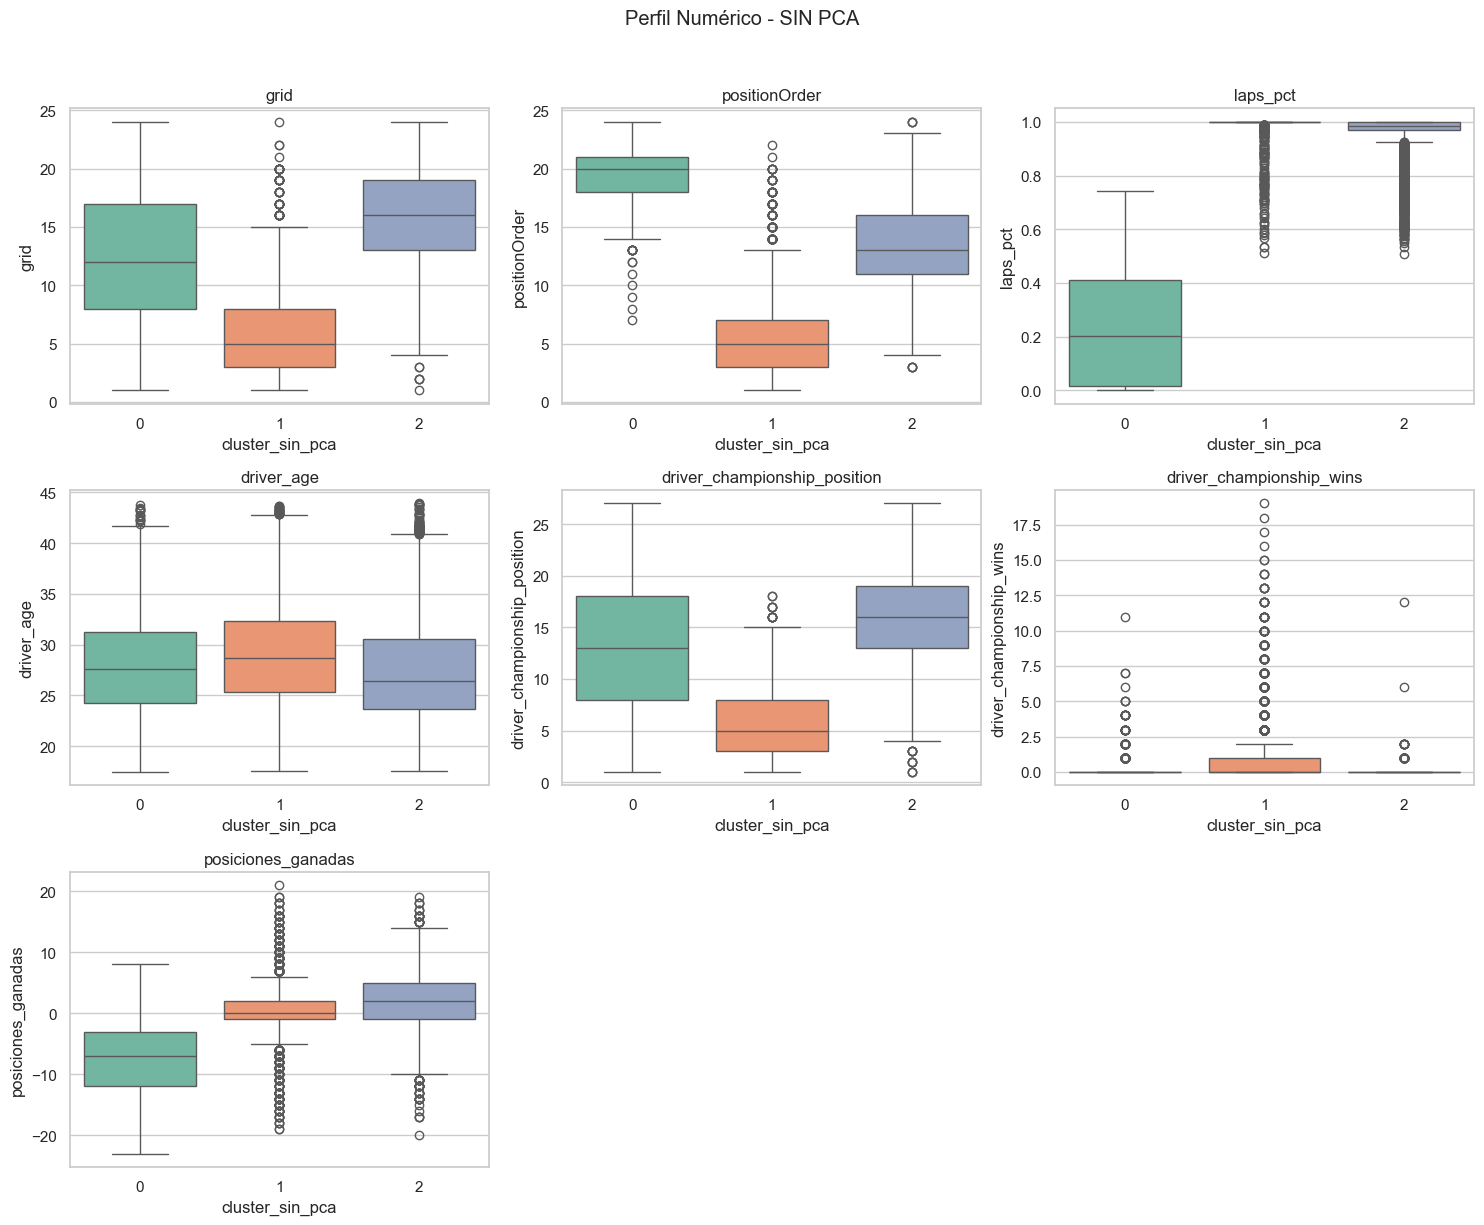


Distribución de resultado_grupo por cluster SIN PCA


resultado_grupo,Fuera del top 10,Ganador,Podio,Top 10
cluster_sin_pca,,,,
0,0.997,0.000,0.000,0.003
1,0.072,0.117,0.231,0.580
2,0.781,0.000,0.001,0.218


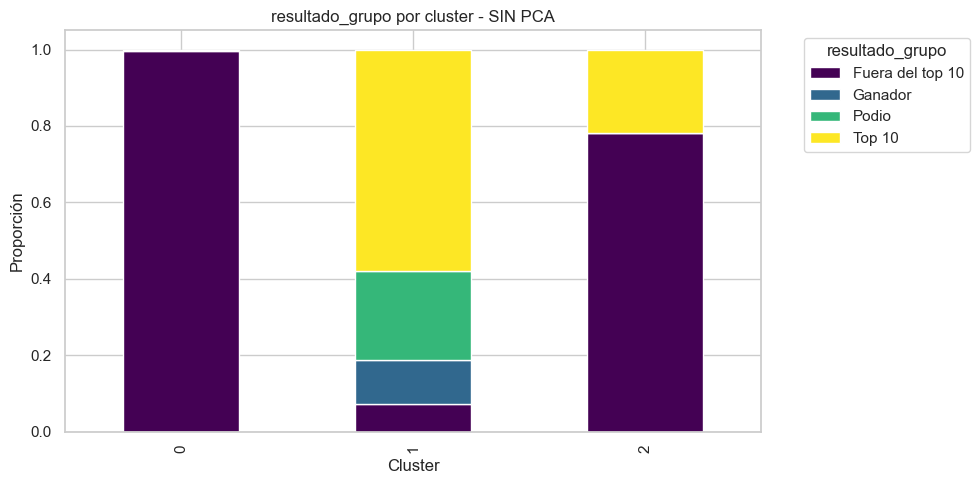


Distribución de largada_grupo por cluster SIN PCA


largada_grupo,Fondo,Pole,Top 10,Top 5
cluster_sin_pca,,,,
0,0.602,0.022,0.240,0.136
1,0.112,0.107,0.374,0.406
2,0.882,0.000,0.112,0.006


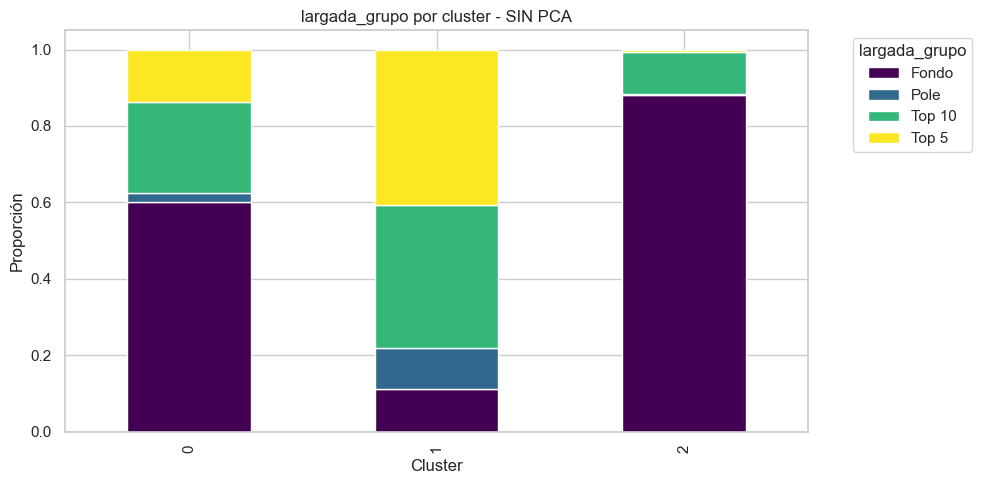


Distribución de status por cluster SIN PCA


status,+1 Lap,+10 Laps,+11 Laps,+12 Laps,+14 Laps,+17 Laps,+2 Laps,+26 Laps,+3 Laps,+4 Laps,+42 Laps,+5 Laps,+6 Laps,+7 Laps,+8 Laps,+9 Laps,Accident,Alternator,Battery,Brake duct,Brakes,Broken wing,Chassis,Clutch,Collision,Collision damage,Cooling system,Crankshaft,Damage,Debris,Differential,Disqualified,Driver Seat,Driveshaft,Drivetrain,ERS,Electrical,Electronics,Engine,Engine fire,Engine misfire,Excluded,Exhaust,Finished,Fire,Front wing,Fuel,Fuel leak,Fuel pressure,Fuel pump,Fuel rig,Fuel system,Gearbox,Halfshaft,Handling,Heat shield fire,Hydraulics,Ignition,Illness,Injured,Launch control,Mechanical,Not restarted,Oil leak,Oil line,Oil pressure,Out of fuel,Overheating,Pneumatics,Power Unit,Power loss,Puncture,Radiator,Rear wing,Refuelling,Retired,Safety,Seat,Spark plugs,Spun off,Stalled,Steering,Suspension,Technical,Throttle,Track rod,Transmission,Turbo,Tyre,Tyre puncture,Undertray,Vibrations,Water leak,Water pressure,Water pump,Wheel,Wheel nut,Wheel rim,Withdrew
cluster_sin_pca,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
0,0.000,0.0,0.0,0.0,0.0,0.0,0.000,0.001,0.000,0.000,0.001,0.000,0.000,0.0,0.000,0.0,0.126,0.001,0.001,0.001,0.037,0.0,0.0,0.008,0.219,0.027,0.0,0.0,0.001,0.001,0.001,0.004,0.001,0.008,0.001,0.002,0.027,0.006,0.115,0.0,0.001,0.0,0.004,0.000,0.0,0.001,0.001,0.001,0.006,0.001,0.001,0.002,0.066,0.002,0.0,0.001,0.053,0.001,0.001,0.002,0.001,0.007,0.001,0.012,0.0,0.002,0.001,0.007,0.001,0.017,0.009,0.006,0.003,0.004,0.001,0.025,0.001,0.0,0.001,0.056,0.001,0.005,0.037,0.001,0.006,0.001,0.014,0.004,0.007,0.0,0.001,0.000,0.005,0.003,0.0,0.013,0.004,0.0,0.017
1,0.112,0.0,0.0,0.0,0.0,0.0,0.004,0.000,0.001,0.000,0.000,0.000,0.000,0.0,0.000,0.0,0.003,0.000,0.000,0.000,0.002,0.0,0.0,0.000,0.003,0.000,0.0,0.0,0.000,0.000,0.000,0.001,0.000,0.000,0.000,0.000,0.001,0.000,0.007,0.0,0.000,0.0,0.001,0.851,0.0,0.000,0.000,0.000,0.001,0.000,0.000,0.001,0.001,0.000,0.0,0.000,0.001,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.0,0.000,0.000,0.000,0.000,0.001,0.000,0.001,0.000,0.000,0.000,0.001,0.000,0.0,0.000,0.001,0.000,0.000,0.001,0.000,0.000,0.000,0.000,0.000,0.001,0.0,0.000,0.000,0.000,0.000,0.0,0.000,0.000,0.0,0.000
2,0.415,0.0,0.0,0.0,0.0,0.0,0.119,0.000,0.033,0.014,0.000,0.004,0.001,0.0,0.001,0.0,0.014,0.000,0.000,0.000,0.008,0.0,0.0,0.001,0.013,0.004,0.0,0.0,0.000,0.000,0.000,0.004,0.000,0.002,0.000,0.000,0.002,0.000,0.021,0.0,0.000,0.0,0.000,0.273,0.0,0.001,0.000,0.000,0.003,0.000,0.000,0.000,0.011,0.000,0.0,0.000,0.005,0.000,0.000,0.000,0.000,0.003,0.000,0.001,0.0,0.001,0.001,0.001,0.000,0.003,0.000,0.001,0.000,0.001,0.000,0.008,0.000,0.0,0.000,0.007,0.000,0.001,0.005,0.001,0.001,0.000,0.002,0.000,0.000,0.0,0.000,0.001,0.000,0.001,0.0,0.002,0.000,0.0,0.000



Distribución de decada por cluster SIN PCA


decada,2000s,2010s,2020s
cluster_sin_pca,,,
0,0.468,0.394,0.138
1,0.350,0.419,0.231
2,0.321,0.461,0.218


In [62]:
# K-Means
km_sin_pca = KMeans(n_clusters=K_FINAL, random_state=RANDOM_STATE, n_init=20)
df_cluster["cluster_sin_pca"] = km_sin_pca.fit_predict(X_sin_pca)

# Perfiles Numéricos (Boxplots)
variables_perfil = variables_cluster_base + ["posiciones_ganadas"]
plot_boxplots_clusters(
    df_cluster, "cluster_sin_pca", variables_perfil, 
    "Perfil Numérico - SIN PCA", "cluster_sin_pca_boxplots.png"
)

# Perfilado Categórico detallado
for var_cat in ["resultado_grupo", "largada_grupo", "status", "decada"]:
    if var_cat in df_cluster.columns:
        print("\n", "="*80)
        print(f"Distribución de {var_cat} por cluster SIN PCA")
        
        # Generar y mostrar tabla
        tabla = perfil_categorico(df_cluster, "cluster_sin_pca", var_cat)
        display(tabla)

        # Graficar y guardar (omitiendo status y decada por exceso de categorías)
        if var_cat not in ["status", "decada"]:
            plot_categorica_fill(
                df_cluster,
                cluster_col="cluster_sin_pca",
                variable_cat=var_cat,
                titulo=f"{var_cat} por cluster - SIN PCA",
                guardar_como=f"cluster_sin_pca_{var_cat}.png"
            )

## 4. Enfoque 2: Clustering CON PCA

Repetimos exactamente el mismo proceso, pero utilizando la matriz ortogonal reducida obtenida mediante Componentes Principales. Este enfoque suele ofrecer agrupaciones más limpias al haber eliminado el ruido y la colinealidad.

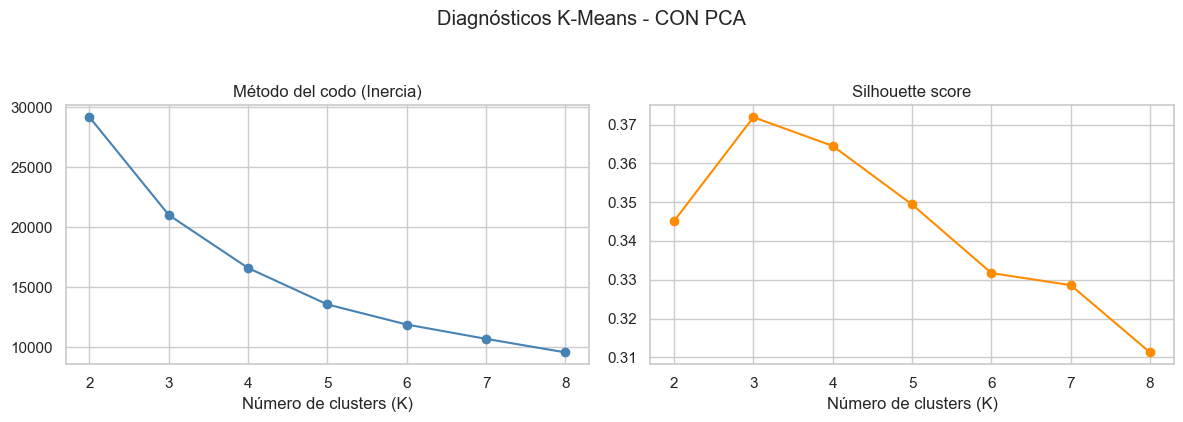

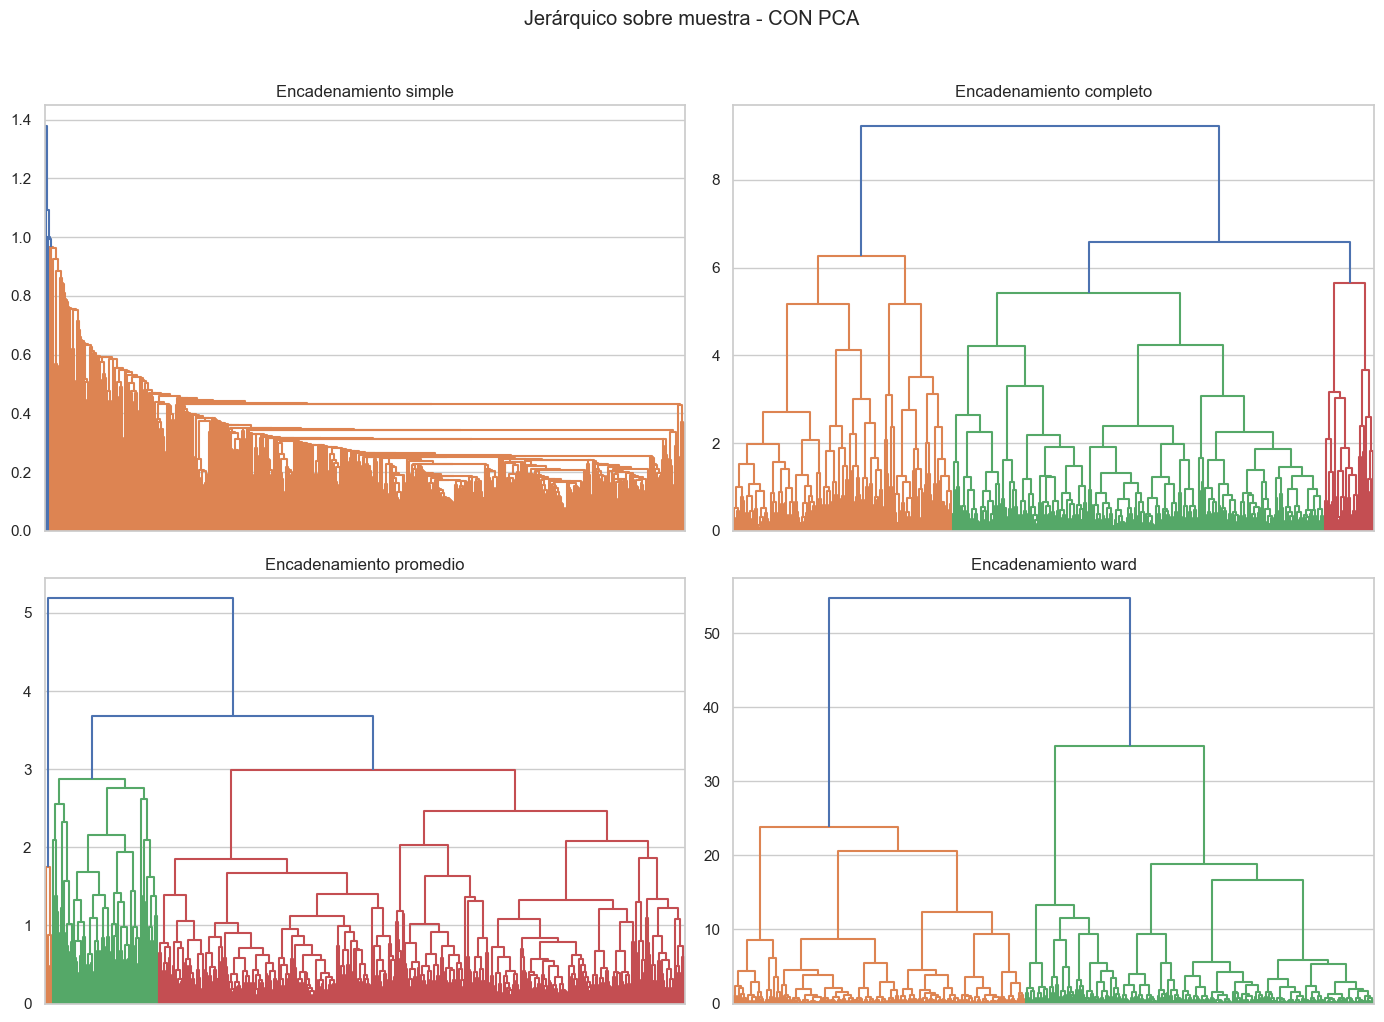

Coeficientes cofenéticos:


,encadenamiento,coeficiente_cofenetico
2,promedio,0.6872
1,completo,0.5944
3,ward,0.5727
0,simple,0.5365


In [63]:
# Diagnósticos
plot_diagnosticos_kmeans(
    X_con_pca, 
    titulo="Diagnósticos K-Means - CON PCA", 
    guardar_como="cluster_con_pca_diagnosticos.png"
)

# Jerárquico sobre muestra
jerarquico_con_pca = analisis_jerarquico_muestra(
    X_con_pca, k_final=K_FINAL, 
    titulo="Jerárquico sobre muestra - CON PCA", 
    guardar_como="cluster_con_pca_dendrograma.png"
)

print("Coeficientes cofenéticos:")
display(jerarquico_con_pca["cofenetico"].round(4))

### 4.1 Aplicación de K-Means y Perfilado (CON PCA)

Ajustamos el modelo definitivo `K=3` sobre la matriz PCA y dibujamos los boxplots y gráficos categóricos. Este será el perfil central de nuestro informe.

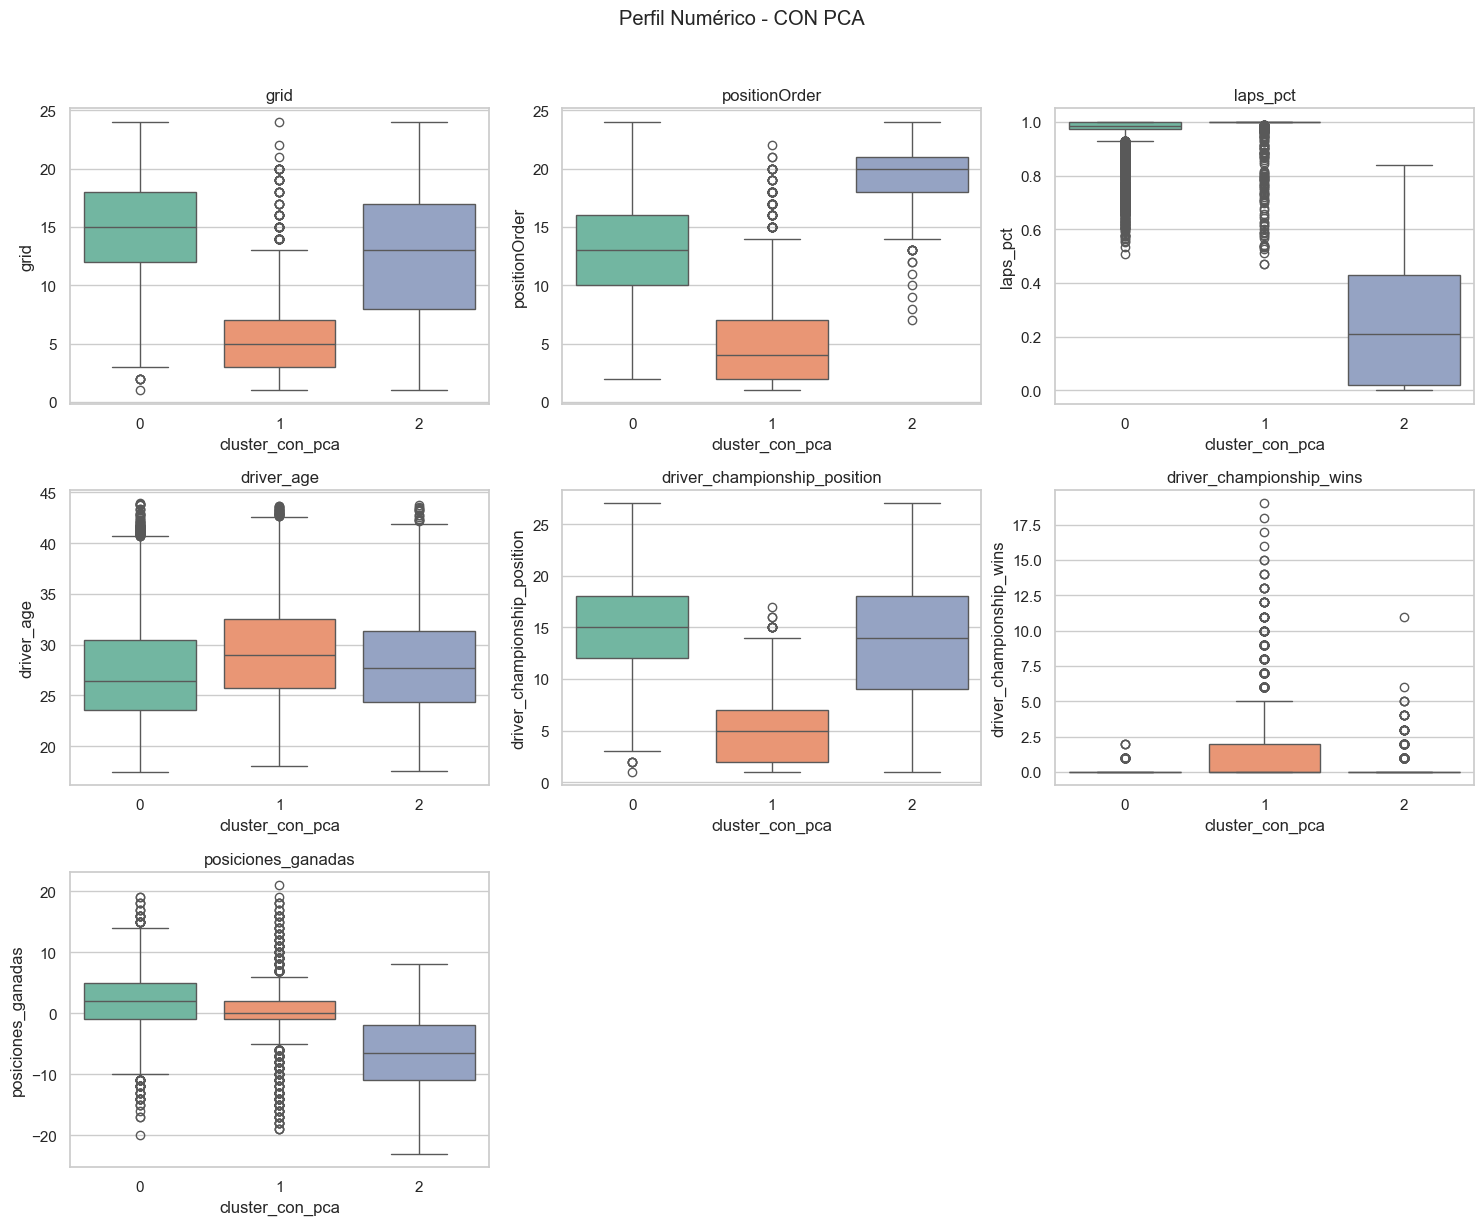


Distribución de resultado_grupo por cluster CON PCA


resultado_grupo,Fuera del top 10,Ganador,Podio,Top 10
cluster_con_pca,,,,
0,0.705,0.000,0.003,0.292
1,0.063,0.135,0.264,0.538
2,0.997,0.000,0.000,0.003


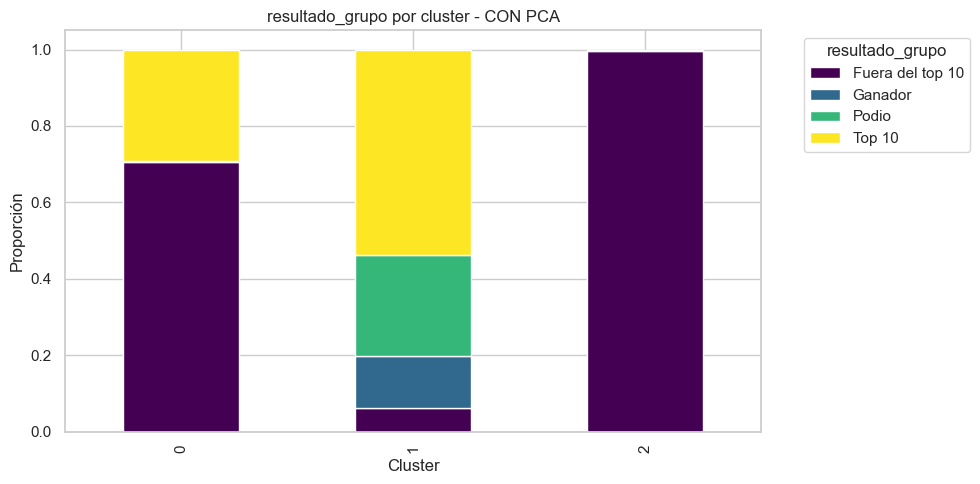


Distribución de largada_grupo por cluster CON PCA


largada_grupo,Fondo,Pole,Top 10,Top 5
cluster_con_pca,,,,
0,0.821,0.000,0.168,0.011
1,0.071,0.125,0.341,0.464
2,0.617,0.020,0.233,0.129


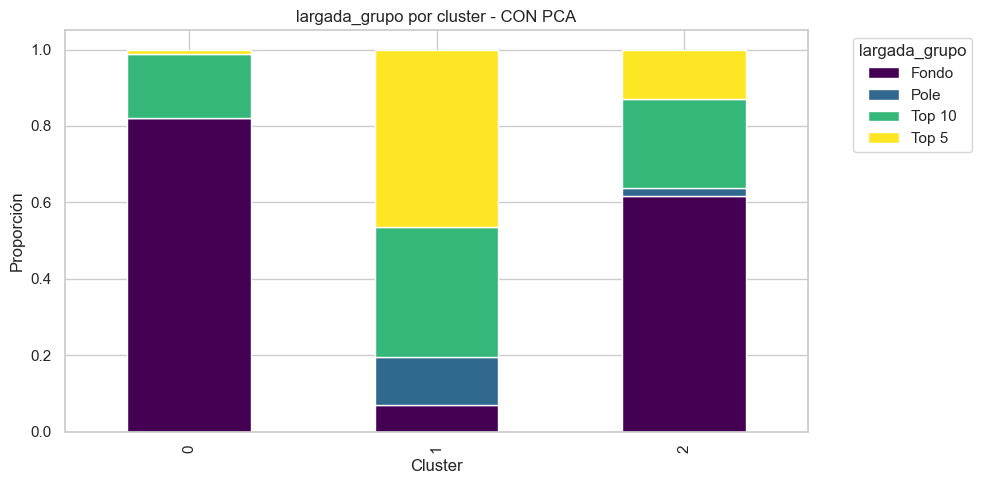


Distribución de status por cluster CON PCA


status,+1 Lap,+10 Laps,+11 Laps,+12 Laps,+14 Laps,+17 Laps,+2 Laps,+26 Laps,+3 Laps,+4 Laps,+42 Laps,+5 Laps,+6 Laps,+7 Laps,+8 Laps,+9 Laps,Accident,Alternator,Battery,Brake duct,Brakes,Broken wing,Chassis,Clutch,Collision,Collision damage,Cooling system,Crankshaft,Damage,Debris,Differential,Disqualified,Driver Seat,Driveshaft,Drivetrain,ERS,Electrical,Electronics,Engine,Engine fire,Engine misfire,Excluded,Exhaust,Finished,Fire,Front wing,Fuel,Fuel leak,Fuel pressure,Fuel pump,Fuel rig,Fuel system,Gearbox,Halfshaft,Handling,Heat shield fire,Hydraulics,Ignition,Illness,Injured,Launch control,Mechanical,Not restarted,Oil leak,Oil line,Oil pressure,Out of fuel,Overheating,Pneumatics,Power Unit,Power loss,Puncture,Radiator,Rear wing,Refuelling,Retired,Safety,Seat,Spark plugs,Spun off,Stalled,Steering,Suspension,Technical,Throttle,Track rod,Transmission,Turbo,Tyre,Tyre puncture,Undertray,Vibrations,Water leak,Water pressure,Water pump,Wheel,Wheel nut,Wheel rim,Withdrew
cluster_con_pca,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
0,0.402,0.0,0.000,0.0,0.0,0.0,0.107,0.000,0.029,0.013,0.000,0.004,0.001,0.0,0.001,0.0,0.012,0.000,0.000,0.000,0.007,0.0,0.0,0.001,0.011,0.004,0.0,0.0,0.000,0.000,0.000,0.003,0.000,0.001,0.000,0.000,0.001,0.000,0.019,0.0,0.000,0.0,0.000,0.322,0.000,0.001,0.000,0.000,0.002,0.000,0.000,0.000,0.010,0.000,0.0,0.000,0.004,0.000,0.000,0.000,0.000,0.002,0.000,0.001,0.0,0.001,0.001,0.001,0.000,0.002,0.000,0.001,0.000,0.001,0.000,0.007,0.000,0.0,0.000,0.006,0.000,0.001,0.004,0.001,0.001,0.000,0.001,0.000,0.001,0.0,0.000,0.001,0.000,0.000,0.0,0.002,0.000,0.0,0.000
1,0.085,0.0,0.000,0.0,0.0,0.0,0.004,0.000,0.001,0.000,0.000,0.000,0.000,0.0,0.000,0.0,0.003,0.000,0.000,0.000,0.002,0.0,0.0,0.001,0.004,0.000,0.0,0.0,0.000,0.000,0.000,0.001,0.000,0.001,0.000,0.000,0.001,0.000,0.007,0.0,0.000,0.0,0.001,0.877,0.000,0.000,0.000,0.000,0.001,0.000,0.000,0.001,0.002,0.000,0.0,0.000,0.001,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.0,0.000,0.000,0.000,0.000,0.001,0.000,0.001,0.000,0.000,0.000,0.001,0.000,0.0,0.000,0.002,0.000,0.000,0.001,0.000,0.000,0.000,0.000,0.000,0.000,0.0,0.000,0.000,0.000,0.001,0.0,0.000,0.000,0.0,0.000
2,0.000,0.0,0.001,0.0,0.0,0.0,0.000,0.001,0.000,0.000,0.001,0.000,0.000,0.0,0.000,0.0,0.125,0.001,0.001,0.001,0.037,0.0,0.0,0.007,0.219,0.028,0.0,0.0,0.001,0.001,0.001,0.003,0.001,0.008,0.001,0.002,0.028,0.006,0.113,0.0,0.001,0.0,0.004,0.000,0.001,0.001,0.001,0.001,0.006,0.001,0.001,0.002,0.064,0.002,0.0,0.001,0.053,0.001,0.001,0.002,0.001,0.008,0.001,0.011,0.0,0.002,0.001,0.007,0.002,0.017,0.009,0.007,0.003,0.003,0.001,0.025,0.001,0.0,0.001,0.055,0.001,0.006,0.036,0.001,0.005,0.001,0.015,0.003,0.007,0.0,0.001,0.001,0.005,0.003,0.0,0.012,0.005,0.0,0.017



Distribución de decada por cluster CON PCA


decada,2000s,2010s,2020s
cluster_con_pca,,,
0,0.325,0.458,0.217
1,0.350,0.415,0.235
2,0.465,0.398,0.137


In [64]:
# K-Means PCA
km_con_pca = KMeans(n_clusters=K_FINAL, random_state=RANDOM_STATE, n_init=20)
df_cluster["cluster_con_pca"] = km_con_pca.fit_predict(X_con_pca)

# Boxplots
plot_boxplots_clusters(
    df_cluster, "cluster_con_pca", variables_perfil, 
    "Perfil Numérico - CON PCA", "cluster_con_pca_boxplots.png"
)

# Perfilado Categórico detallado
for var_cat in ["resultado_grupo", "largada_grupo", "status", "decada"]:
    if var_cat in df_cluster.columns:
        print("\n", "="*80)
        print(f"Distribución de {var_cat} por cluster CON PCA")
        
        # Generar y mostrar tabla
        tabla = perfil_categorico(df_cluster, "cluster_con_pca", var_cat)
        display(tabla)

        # Graficar y guardar (omitiendo status y decada por exceso de categorías)
        if var_cat not in ["status", "decada"]:
            plot_categorica_fill(
                df_cluster,
                cluster_col="cluster_con_pca",
                variable_cat=var_cat,
                titulo=f"{var_cat} por cluster - CON PCA",
                guardar_como=f"cluster_con_pca_{var_cat}.png"
            )

## 7. Interpretación para el Informe Final

La segmentación final utilizando la matriz de Componentes Principales (PCA) con un **K = 3** permitió distinguir de manera clara e interpretable tres perfiles deportivos de participación en la Fórmula 1. 

*(Nota: Los números de cluster `0, 1, 2` asignados por el algoritmo pueden variar en el orden según la semilla aleatoria, pero los perfiles subyacentes se mantienen).*

### Perfil A: Carreras problemáticas o abandonos
Agrupa observaciones con desarrollos de carrera muy negativos. Se caracteriza por una baja proporción de vueltas completadas (`laps_pct`), una pérdida generalizada de posiciones y una alta asociación con abandonos por fallas mecánicas o incidentes. Representa la frustración competitiva, independiente de si la clasificación inicial fue buena o mala.

### Perfil B: Finalizadores de rendimiento medio-bajo
Reúne a los pilotos de la zona media y baja de la parrilla. Su principal característica es la consistencia de llegada (altos valores de `laps_pct`), pero carecen de velocidad punta. Suelen largar desde el fondo y terminar fuera de la zona de puntos (Top 10), representando al núcleo de constructores y corredores que corren por completar la prueba sin aspiraciones directas al título.

### Perfil C: Alto rendimiento competitivo
Es la élite del dataset. Concentra observaciones con posiciones de largada privilegiadas (`grid` cercano a 1), resultados finales en podios o Top 5, y una fuerte acumulación de victorias en el campeonato. No solo largan adelante, sino que demuestran fiabilidad al completar casi siempre el 100% de las vueltas, traduciendo buenas clasificaciones en puntos consolidados.